In [1]:
!pip install rasterio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 102.7 MB/s eta 0:00:0000:0100:01


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


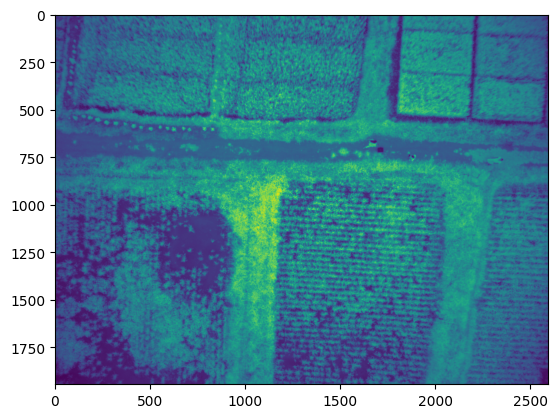

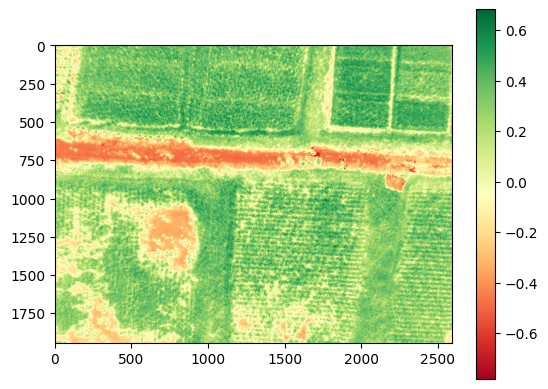

In [2]:
import rasterio
from rasterio import plot
import matplotlib.pyplot as plt
import numpy as np
import os
# {We read the R band}
# imgPath = ’C:/Img/’
red = rasterio.open('/kaggle/input/msi-files/DJI_20230814123320_0001_MS_R.TIF')
# {We read the NIR band} %leemos la banda NIR
nir = rasterio.open('/kaggle/input/msi-files/DJI_20230814123320_0001_MS_NIR.TIF')
# {We visualize the image}
plot.show(nir)
#{We convert to float}
red = red.read(1).astype('float64')
nir = nir.read(1).astype('float64')
# {Error handling in the division}
np.seterr(divide='ignore', invalid='ignore')
# {We calculate NDVI using numpy arrays}
# {Empty cells or cells}
# {no data is reported as zero.}
ndvi = np.where((nir + red) == 0., 0,
(nir - red) / (nir + red))
# {We plot the results with the colors}
#{Red, Yellow and Green}
plt.imshow(ndvi, cmap='RdYlGn')
# {We add color palette}
plt.colorbar()


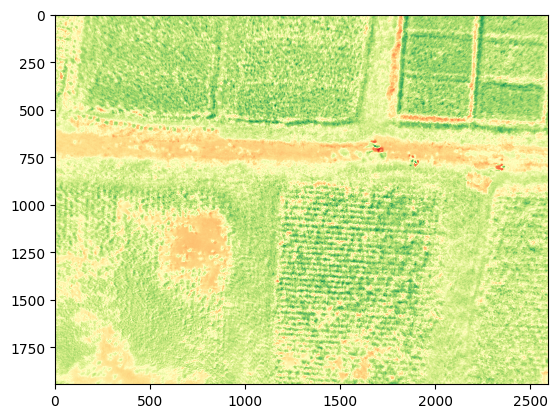

In [3]:
# Read band G
green = rasterio.open('/kaggle/input/msi-files/DJI_20230814123320_0001_MS_G.TIF')
green = green.read(1).astype('float64')
# We compute GNDVI using numpy arrays
gndvi = np.where((nir + green) == 0., 0,
(nir - green) / (nir + green))
plt.imshow(gndvi, cmap='RdYlGn')

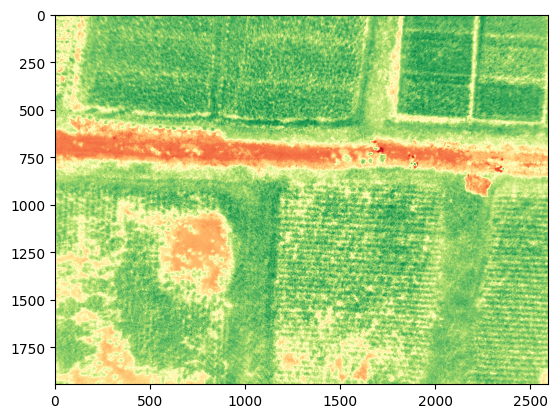

In [4]:

savi = ((nir - red) / (nir + red + 0.5)) * (1 + 0.5)
plt.imshow(savi, cmap='RdYlGn')

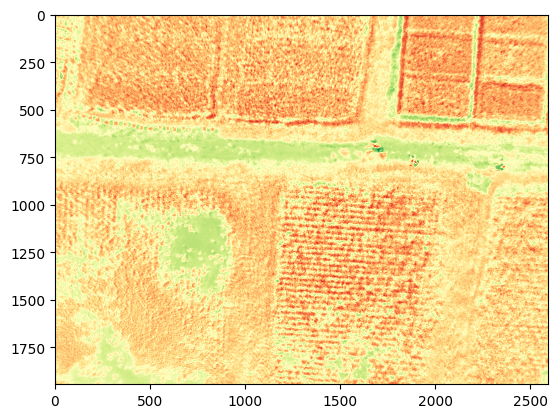

In [5]:
ndwi = np.where((green + nir) == 0, 0,
(green - nir) / (green + nir))
plt.imshow(ndwi, cmap='RdYlGn')

In [6]:
import rasterio
import numpy as np

# 1. Read bands (example paths)
with rasterio.open("/kaggle/input/msi-files/DJI_20230814123320_0001_MS_R.TIF") as red_src:
    red = red_src.read(1).astype("float32")
    profile = red_src.profile

with rasterio.open("/kaggle/input/msi-files/DJI_20230814123320_0001_MS_NIR.TIF") as nir_src:
    nir = nir_src.read(1).astype("float32")

with rasterio.open("/kaggle/input/msi-files/DJI_20230814123320_0001_MS_G.TIF") as green_src:
    green = green_src.read(1).astype("float32")

# 2. Avoid division by zero
eps = 1e-6
ndvi = (nir - red) / (nir + red + eps)
ndwi = (green - nir) / (green + nir + eps)

# 3. Save NDVI and NDWI maps as GeoTIFFs (for QGIS or figures)
profile.update(dtype=rasterio.float32)

with rasterio.open("ndvi.tif", "w", **profile) as dst:
    dst.write(ndvi, 1)

with rasterio.open("ndwi.tif", "w", **profile) as dst:
    dst.write(ndwi, 1)


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


In [7]:
from scipy import ndimage

# Binary mask for unhealthy
unhealthy_mask = ndvi < 0.2

# Label connected components
labels, num = ndimage.label(unhealthy_mask)

# For each region, get bounding boxes
slices = ndimage.find_objects(labels)
bboxes = []
for sl in slices:
    rmin, rmax = sl[0].start, sl[0].stop
    cmin, cmax = sl[1].start, sl[1].stop
    bboxes.append((rmin, rmax, cmin, cmax))


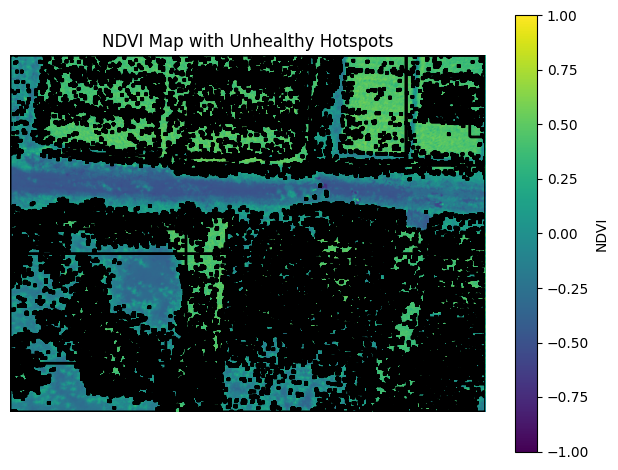

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots()
im = ax.imshow(ndvi, vmin=-1, vmax=1)  # NDVI heatmap
plt.colorbar(im, ax=ax, label="NDVI")

for (rmin, rmax, cmin, cmax) in bboxes:
    width = cmax - cmin
    height = rmax - rmin
    rect = FancyBboxPatch(
        (cmin, rmin),
        width,
        height,
        boxstyle="round,pad=0.1,rounding_size=10",
        linewidth=2,
        fill=False
    )
    ax.add_patch(rect)

ax.set_title("NDVI Map with Unhealthy Hotspots")
plt.axis("off")
plt.tight_layout()
plt.savefig("ndvi_hotspots.png", dpi=300)


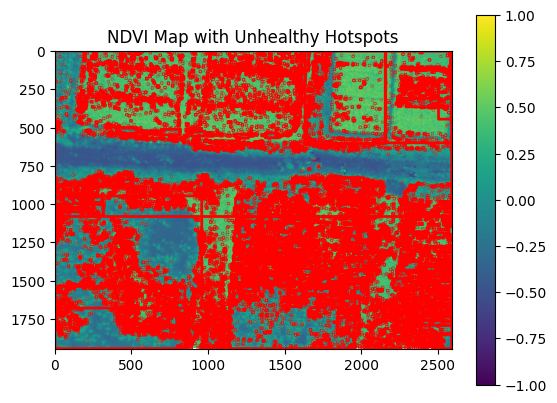

In [9]:
fig, ax = plt.subplots()
im = ax.imshow(ndvi, cmap='viridis', vmin=-1, vmax=1)

# Draw rectangles only for detected regions
for (rmin, rmax, cmin, cmax) in bboxes:
    rect = FancyBboxPatch(
        (cmin, rmin),
        cmax - cmin,
        rmax - rmin,
        boxstyle="round,pad=0.2",
        edgecolor="red",
        facecolor="none",
        linewidth=2
    )
    ax.add_patch(rect)

plt.colorbar(im, ax=ax)
plt.title("NDVI Map with Unhealthy Hotspots")
plt.show()


In [10]:
ax.imshow(unhealthy_mask, cmap="Reds", alpha=0.25)
